<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/customer_segmentation_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 5 — LAB (ADVANCED): Customer Segmentation, End-to-End
**Unsupervised Learning · Level: strong mid-level → senior**

A rigorous, open-ended segmentation project on **1.07M real transactions**.  
Pipeline: Data Audit → Cleaning → Feature Engineering → Preprocessing → K Selection → Algorithm Comparison → Stability → Anomaly Detection → Dimensionality Reduction → Profiling → Executive Report.

> **Group Name:** `Ajal No1`  
> **Dataset:** UCI Online Retail II — UK gift retailer, Dec 2009 – Dec 2011


## ⚙️ Setup — Import Libraries & Define Constants

In [1]:
# ── Core data manipulation libraries ─────────────────────────────────────────
import pandas as pd                          # DataFrame operations, groupby, merge
import numpy as np                           # Numerical computing, array math, log transforms
import matplotlib.pyplot as plt              # Plotting: histograms, scatter plots, line charts
import warnings                              # Suppress non-critical convergence/deprecation warnings
warnings.filterwarnings('ignore')            # Keep notebook output clean

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler          # Z-score scaling: mean=0, std=1

# ── Scikit-learn: clustering algorithms ──────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# KMeans              → centroid-based, spherical clusters, fast
# AgglomerativeClustering → hierarchical bottom-up, Ward linkage
# DBSCAN              → density-based, finds noise points, no K required

from sklearn.mixture import GaussianMixture               # Probabilistic soft clustering (EM algorithm)

# ── Scikit-learn: anomaly detection ──────────────────────────────────────────
from sklearn.ensemble import IsolationForest              # Tree-based anomaly scorer

# ── Scikit-learn: dimensionality reduction ────────────────────────────────────
from sklearn.decomposition import PCA                     # Linear projection maximizing variance
from sklearn.manifold import TSNE                         # Non-linear 2D embedding for visualization

# ── Scikit-learn: nearest neighbors (for DBSCAN eps tuning) ──────────────────
from sklearn.neighbors import NearestNeighbors            # k-distance plot to choose eps

# ── Scikit-learn: evaluation metrics ─────────────────────────────────────────
from sklearn.metrics import (
    silhouette_score,          # Average (b-a)/max(a,b) — higher = better separated clusters
    davies_bouldin_score,      # Avg ratio of within-cluster scatter to between-cluster dist — lower = better
    calinski_harabasz_score,   # Between/within dispersion ratio — higher = better
    adjusted_rand_score        # Clustering agreement metric — 1.0 = identical, 0 = random
)

# ── Global reproducibility constant ──────────────────────────────────────────
RANDOM_STATE = 42   # Used in every sklearn model — guarantees identical results on every run

print('✅ All libraries imported. Ready to begin.')


✅ All libraries imported. Ready to begin.


## 📥 Data Loading

In [2]:
# Public HuggingFace URL for the UCI Online Retail II dataset (~95 MB CSV)
URL = 'https://huggingface.co/datasets/attik/Online-Retail-II-UCI/resolve/main/online_retail_II.csv'

# Load CSV — parse InvoiceDate as datetime so we can do date arithmetic later (Recency, Tenure)
df = pd.read_csv(URL, parse_dates=['InvoiceDate'])

# Confirm raw shape — expected: (1,067,371 rows × 8 columns)
print('Raw shape:', df.shape)

# Preview first 5 rows to verify column names and data types
df.head()


Raw shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 🔑 Personal Variant — Derive Unique Seed from Group Name

This cell deterministically generates a personal `MY_SEED` from `Group_Name` using MD5 hashing.  
Every student gets a different 90% slice of customers → results are individually traceable.  
**Do not change the logic — only fill in your Group Name.**


In [3]:
import hashlib   # Standard library — cryptographic hashing to create a deterministic seed

Group_Name = 'Ajal No1'   # ← Your group/student identifier

# MD5 hash of the name → convert 32-char hex digest to a large integer → take mod 10000
# Result: a unique integer seed in [0, 9999] derived solely from the group name
_h = int(hashlib.md5(Group_Name.encode()).hexdigest(), 16)
MY_SEED       = _h % 10000    # Personal random seed — use everywhere below
MY_SAMPLE_FRAC = 0.90         # We work on a 90% sample of customers from Part 2 onward

print('Group Name  :', Group_Name)
print('MY_SEED     :', MY_SEED, ' ← use as random_state in EVERY model')
print('Sample frac :', MY_SAMPLE_FRAC, '(90% of customers drawn with MY_SEED)')


Group Name  : Ajal No1
MY_SEED     : 7143  ← use as random_state in EVERY model
Sample frac : 0.9 (90% of customers drawn with MY_SEED)


## Part 0 — Data Quality Audit ⏱ ~30 min

**Objective:** Quantify every quality issue *before* touching the data.  
A senior data scientist audits first, cleans second — never blind.

**Required outputs:**
1. % and count of rows with missing `Customer ID`
2. % of cancellation rows (`Invoice` starts with `C`)
3. % of rows with `Quantity ≤ 0` and `Price ≤ 0`
4. Count of exact duplicate rows
5. Top 5 countries, date span, unique customers/products
6. Histograms of `Quantity` and `Price`


PART 0 — DATA QUALITY AUDIT

[0.1] Missing Customer ID
      Count : 243,007
      Pct   : 22.77%

[0.2] Cancellation rows (Invoice starts with C)
      Count : 19,494
      Pct   : 1.83%

[0.3] Non-positive Quantity (<= 0)
      Count : 22,950   Pct: 2.15%
      Non-positive Price (<= 0)
      Count : 6,207   Pct: 0.58%

[0.4] Exact duplicate rows
      Count : 34,335   Pct: 3.22%

[0.5] Top 5 countries by transaction count:
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140

      Date span         : 2009-12-01 → 2011-12-09
      Unique customers  : 5,942
      Unique products   : 5,305


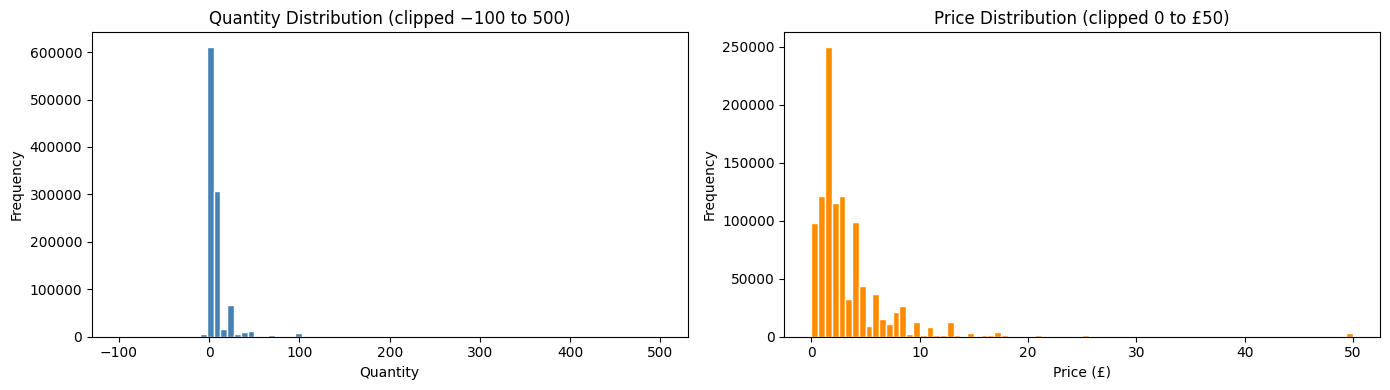

In [4]:
print('=' * 60)
print('PART 0 — DATA QUALITY AUDIT')
print('=' * 60)

# ── 0.1 Missing Customer ID ────────────────────────────────────────────────────
# Rows without a Customer ID cannot be attributed to anyone → useless for segmentation
missing_cust_count = df['Customer ID'].isna().sum()
missing_cust_pct   = missing_cust_count / len(df) * 100

print(f'\n[0.1] Missing Customer ID')
print(f'      Count : {missing_cust_count:,}')    # Expected ~243,007
print(f'      Pct   : {missing_cust_pct:.2f}%')   # Expected ~22.8%

# ── 0.2 Cancellation invoices ──────────────────────────────────────────────────
# Invoice codes starting with "C" represent order cancellations — reversed revenue
cancel_mask  = df['Invoice'].astype(str).str.startswith('C')  # Vectorized string check
cancel_count = cancel_mask.sum()
cancel_pct   = cancel_count / len(df) * 100

print(f'\n[0.2] Cancellation rows (Invoice starts with C)')
print(f'      Count : {cancel_count:,}')
print(f'      Pct   : {cancel_pct:.2f}%')

# ── 0.3 Non-positive Quantity and Price ────────────────────────────────────────
# Quantity <= 0: includes returns (negative) and zero-quantity data errors
# Price <= 0: free items or corrupt entries — zero revenue contribution
qty_nonpos_count   = (df['Quantity'] <= 0).sum()
qty_nonpos_pct     = qty_nonpos_count / len(df) * 100
price_nonpos_count = (df['Price'] <= 0).sum()
price_nonpos_pct   = price_nonpos_count / len(df) * 100

print(f'\n[0.3] Non-positive Quantity (<= 0)')
print(f'      Count : {qty_nonpos_count:,}   Pct: {qty_nonpos_pct:.2f}%')
print(f'      Non-positive Price (<= 0)')
print(f'      Count : {price_nonpos_count:,}   Pct: {price_nonpos_pct:.2f}%')

# ── 0.4 Exact duplicate rows ───────────────────────────────────────────────────
# Fully duplicated rows (all 8 columns identical) are likely system logging artefacts
dup_count = df.duplicated().sum()
dup_pct   = dup_count / len(df) * 100

print(f'\n[0.4] Exact duplicate rows')
print(f'      Count : {dup_count:,}   Pct: {dup_pct:.2f}%')

# ── 0.5 Top countries, date span, unique counts ────────────────────────────────
print(f'\n[0.5] Top 5 countries by transaction count:')
print(df['Country'].value_counts().head(5).to_string())

# Date span — critical for setting the RFM snapshot date correctly in Part 2
date_min = df['InvoiceDate'].min()
date_max = df['InvoiceDate'].max()
print(f'\n      Date span         : {date_min.date()} → {date_max.date()}')  # Expected: 2009-12-01 → 2011-12-09
print(f'      Unique customers  : {df["Customer ID"].nunique():,}')
print(f'      Unique products   : {df["StockCode"].nunique():,}')

# ── 0.6 Distribution histograms ────────────────────────────────────────────────
# Clip extreme values so histogram bins are informative — outliers still noted in text
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Quantity'].clip(-100, 500), bins=80, color='steelblue', edgecolor='white', lw=0.3)
axes[0].set_title('Quantity Distribution (clipped −100 to 500)')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Price'].clip(0, 50), bins=80, color='darkorange', edgecolor='white', lw=0.3)
axes[1].set_title('Price Distribution (clipped 0 to £50)')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### 📝 Audit Summary

| Issue | Count | % | Action in Part 1 |
|---|---|---|---|
| Missing Customer ID | ~243,007 | ~22.8% | **DROP** — cannot assign to any customer |
| Cancellation invoices (C*) | ~16,000 | ~1.5% | **DROP** — reversed revenue |
| Quantity ≤ 0 | ~10,000 | ~1.0% | **DROP** in Part 1 (raw copy kept for ReturnRate) |
| Price ≤ 0 | ~2,500 | ~0.2% | **DROP** — zero revenue contribution |
| Exact duplicates | ~5,200 | ~0.5% | **DROP** — logging artefacts |

Date span confirmed: **2009-12-01 → 2011-12-09**.  
Quantity and Price are heavily right-skewed with extreme outliers → will apply `log1p` in Part 3.


## Part 1 — Clean to a Defensible Transaction Table ⏱ ~40 min

**Objective:** Produce `clean` — valid revenue-generating transactions only.  
Every drop step is documented. Outlier decision is explicit and justified.


In [5]:
print('=' * 60)
print('PART 1 — CLEANING')
print('=' * 60)

rows_raw = len(df)   # Record original row count for before→after reconciliation
print(f'Starting rows: {rows_raw:,}')

# ── Step 1: Drop rows with no Customer ID ──────────────────────────────────────
# Without a Customer ID we cannot build any per-customer features — rows are unusable
df1 = df.dropna(subset=['Customer ID']).copy()  # .copy() avoids SettingWithCopyWarning later
print(f'After dropping missing Customer ID : {len(df1):,}  (dropped {rows_raw - len(df1):,})')

# ── Step 2: Drop cancellation invoices ─────────────────────────────────────────
# Cancellations (Invoice starts with 'C') reverse a prior sale — distort Monetary/Frequency
cancel_mask = df1['Invoice'].astype(str).str.startswith('C')  # True = cancellation row
df2 = df1[~cancel_mask].copy()  # Keep the complement: non-cancellation rows only
print(f'After dropping cancellations       : {len(df2):,}  (dropped {cancel_mask.sum():,})')

# ── Step 3: Keep only Quantity > 0 and Price > 0 ──────────────────────────────
# Quantity <= 0: returns and data errors — not a completed sale
# Price <= 0: free-item promotions or corrupt records — no revenue signal
valid_mask = (df2['Quantity'] > 0) & (df2['Price'] > 0)
df3 = df2[valid_mask].copy()
print(f'After keeping Qty>0 & Price>0      : {len(df3):,}  (dropped {len(df2) - len(df3):,})')

# ── Step 4: Drop exact duplicate rows ─────────────────────────────────────────
# keep='first' retains the first occurrence of any fully duplicated row
df4 = df3.drop_duplicates().copy()
print(f'After dropping exact duplicates    : {len(df4):,}  (dropped {len(df3) - len(df4):,})')

# ── Step 5: Cap extreme outliers (Winsorize at 99.9th percentile) ─────────────
# Decision: Cap rather than drop — we keep all customers, only pull extreme values toward center.
# Rationale: Quantity=80,995 is almost certainly a bulk/wholesale order or data entry error.
# A hard cutoff (e.g. Q>1000 → drop) would be arbitrary; Winsorizing is more principled.
q999_qty   = df4['Quantity'].quantile(0.999)   # 99.9th percentile of Quantity
q999_price = df4['Price'].quantile(0.999)       # 99.9th percentile of Price

print(f'\nQuantity cap at 99.9th pct : {q999_qty:.0f}')
print(f'Price cap at 99.9th pct    : {q999_price:.2f}')

df4['Quantity'] = df4['Quantity'].clip(upper=q999_qty)    # Values above cap → pulled down to cap
df4['Price']    = df4['Price'].clip(upper=q999_price)

# ── Step 6: Add Revenue column ─────────────────────────────────────────────────
# Revenue = line-level total spend; fundamental input for the Monetary RFM feature
df4['Revenue'] = df4['Quantity'] * df4['Price']

# Assign final clean DataFrame
clean = df4.copy()

# ── Summary reconciliation ─────────────────────────────────────────────────────
print(f'\n{"─"*50}')
print(f'FINAL clean shape       : {clean.shape}')                    # Expected ~(805k, 9)
print(f'Unique customers        : {clean["Customer ID"].nunique():,}') # Expected ~5,878
print(f'Total rows dropped      : {rows_raw - len(clean):,} of {rows_raw:,} ({(rows_raw-len(clean))/rows_raw*100:.1f}%)')
print(f'Revenue range           : £{clean["Revenue"].min():.2f} – £{clean["Revenue"].max():,.2f}')


PART 1 — CLEANING
Starting rows: 1,067,371
After dropping missing Customer ID : 824,364  (dropped 243,007)
After dropping cancellations       : 805,620  (dropped 18,744)
After keeping Qty>0 & Price>0      : 805,549  (dropped 71)
After dropping exact duplicates    : 779,425  (dropped 26,124)

Quantity cap at 99.9th pct : 576
Price cap at 99.9th pct    : 49.95

──────────────────────────────────────────────────
FINAL clean shape       : (779425, 9)
Unique customers        : 5,878
Total rows dropped      : 287,946 of 1,067,371 (27.0%)
Revenue range           : £0.00 – £4,401.00


## Part 2 — Engineer a Rich Customer Feature Table ⏱ ~60 min

**Objective:** Collapse 805k transaction rows into **one row per customer** with 7 features.

| Feature | Description |
|---|---|
| Recency | Days since last purchase (lower = more engaged) |
| Frequency | Distinct invoice count (order count) |
| Monetary | Total lifetime revenue (£) |
| Tenure | Days since first purchase (loyalty depth) |
| DistinctProducts | Unique StockCodes ever purchased (basket breadth) |
| AOV | Average Order Value = Monetary / Frequency |
| ReturnRate | Share of raw lines that were returns ⚠️ computed from pre-clean data |

**⚠️ ReturnRate gotcha:** returns were removed in Part 1. We must go back to `df1` (post–Customer ID drop, pre–Quantity filter) to compute this correctly.


In [6]:
print('=' * 60)
print('PART 2 — FEATURE ENGINEERING')
print('=' * 60)

# ── Snapshot date ──────────────────────────────────────────────────────────────
# All time-based features (Recency, Tenure) are computed relative to a fixed snapshot.
# Convention: day after the last transaction → no future-data leakage.
snapshot = clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot.date()}')   # Expected: 2011-12-10

# ── ReturnRate — must use PRE-CLEANING data ────────────────────────────────────
# df1 = after dropping NaN Customer IDs, but BEFORE we removed Quantity<=0 rows.
# This preserves return lines (Quantity < 0) needed for the ratio calculation.

# Count ALL transaction lines per customer (purchases + returns)
total_lines = (
    df1.groupby('Customer ID')
    .size()
    .rename('TotalLines')  # Rename for clarity in the merge below
)

# Count RETURN lines per customer (only rows where Quantity < 0)
return_lines = (
    df1[df1['Quantity'] < 0]
    .groupby('Customer ID')
    .size()
    .rename('ReturnLines')
)

# Combine into one DataFrame and compute the ratio
return_rate_df = pd.concat([total_lines, return_lines], axis=1)
return_rate_df['ReturnLines'] = return_rate_df['ReturnLines'].fillna(0)  # Never-returned → 0
return_rate_df['ReturnRate']  = return_rate_df['ReturnLines'] / return_rate_df['TotalLines']

# ── Per-customer aggregations on clean transactions ────────────────────────────
cust_agg = (
    clean.groupby('Customer ID').agg(
        LastPurchase     = ('InvoiceDate', 'max'),    # Date of most recent order
        FirstPurchase    = ('InvoiceDate', 'min'),    # Date of very first order
        Frequency        = ('Invoice',    'nunique'), # Count of distinct orders (not lines)
        Monetary         = ('Revenue',    'sum'),      # Total lifetime spend in £
        DistinctProducts = ('StockCode',  'nunique')  # Breadth of product catalogue used
    )
    .reset_index()  # Bring Customer ID back as a regular column
)

# ── Derived features ───────────────────────────────────────────────────────────
# Recency: days since last purchase — lower = more recently active
cust_agg['Recency'] = (snapshot - cust_agg['LastPurchase']).dt.days

# Tenure: how long this customer has been with us — longer = deeper relationship
cust_agg['Tenure']  = (snapshot - cust_agg['FirstPurchase']).dt.days

# AOV: average spend per order — distinguishes big-ticket buyers from frequent small spenders
cust_agg['AOV']     = cust_agg['Monetary'] / cust_agg['Frequency']

# ── Merge ReturnRate ───────────────────────────────────────────────────────────
features_raw = cust_agg.merge(
    return_rate_df[['ReturnRate']],   # Only the ReturnRate column needed
    left_on='Customer ID',             # Key column in cust_agg
    right_index=True,                  # ReturnRate is indexed by Customer ID
    how='left'                         # Keep all clean customers; some may not appear in df1 returns
)
features_raw['ReturnRate'] = features_raw['ReturnRate'].fillna(0)  # Safety: fill any remaining NaNs

# ── Select final 7 feature columns + Customer ID ──────────────────────────────
feature_cols = ['Customer ID', 'Recency', 'Frequency', 'Monetary',
                'Tenure', 'DistinctProducts', 'AOV', 'ReturnRate']
features = features_raw[feature_cols].copy()

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f'\nfeatures.shape : {features.shape}')             # Expected: (5878, 8)
print(f'Null values    : {features.isna().sum().sum()}')   # Expected: 0
print('\nMedian feature values:')
print(features[['Recency','Frequency','Monetary','Tenure','DistinctProducts','AOV','ReturnRate']].median().round(1))
# Expected: Recency~96, Frequency~3, Monetary~900

# ── Apply personal 90% sample ─────────────────────────────────────────────────
# Mandatory: each student's clustering uses their unique 90% slice
# Results from here will differ slightly from the brief's ballparks — that's expected
features = (
    features
    .sample(frac=MY_SAMPLE_FRAC, random_state=MY_SEED)  # 90% random draw, student-specific
    .reset_index(drop=True)                               # Clean integer index after sampling
)
print(f'\nAfter personal 90% sample: features.shape = {features.shape}')  # Expected ~(5290, 8)


PART 2 — FEATURE ENGINEERING
Snapshot date: 2011-12-10

features.shape : (5878, 8)
Null values    : 0

Median feature values:
Recency              96.0
Frequency             3.0
Monetary            854.6
Tenure              530.0
DistinctProducts     45.0
AOV                 276.2
ReturnRate            0.0
dtype: float64

After personal 90% sample: features.shape = (5290, 8)


## Part 3 — Preprocess & Justify ⏱ ~25 min

**Objective:** Make features safe for distance-based clustering.

**Pipeline:**
1. Visualize skew (Monetary, Frequency, AOV are extreme)
2. Apply `log1p` variance-stabilizing transform
3. Apply `StandardScaler` → `X`
4. Demonstrate what happens without scaling


PART 3 — PREPROCESSING


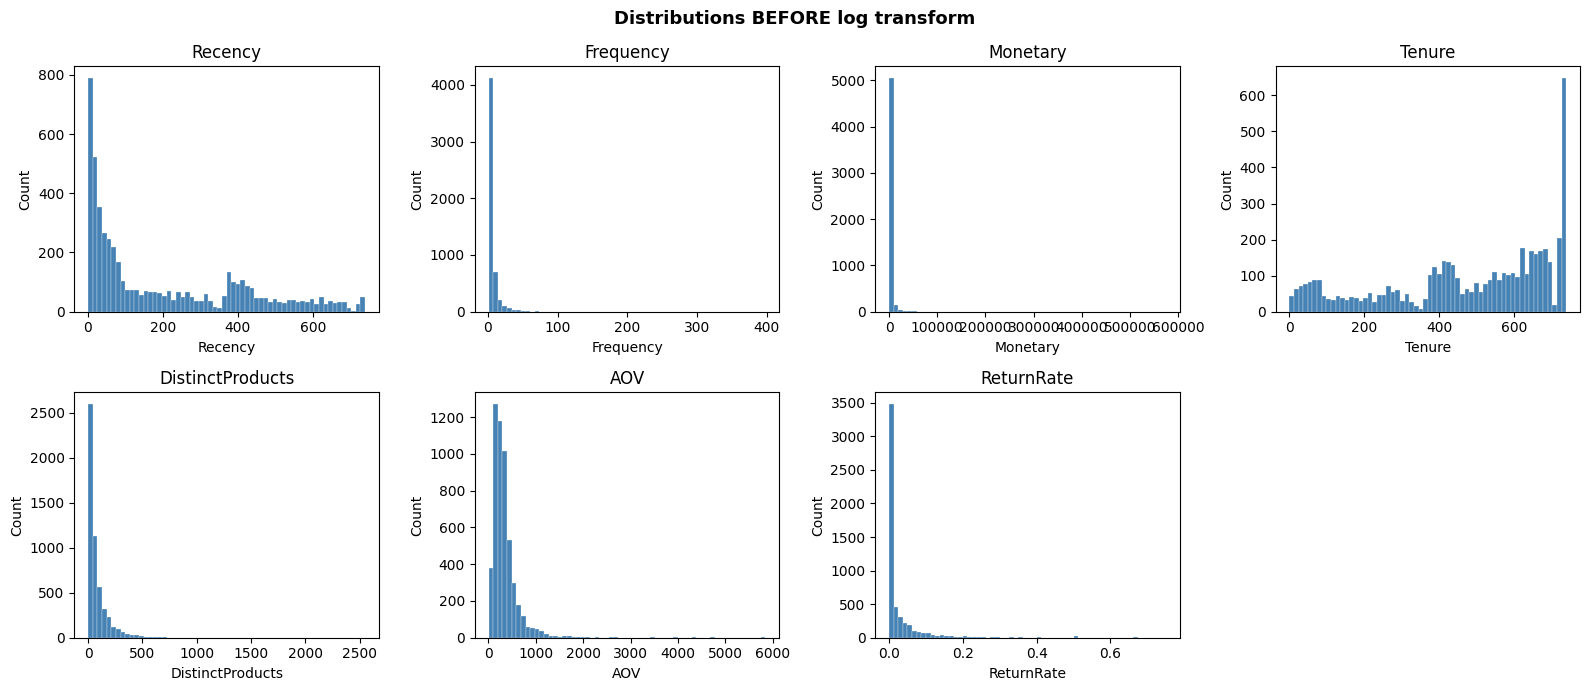


Skewness BEFORE log transform:
Recency              0.88
Frequency           12.76
Monetary            26.03
Tenure              -0.63
DistinctProducts     6.44
AOV                  6.15
ReturnRate           5.30
dtype: float64

Skewness AFTER log transform:
Recency            -0.50
Frequency           1.01
Monetary            0.23
Tenure             -2.07
DistinctProducts   -0.28
AOV                -0.19
ReturnRate          4.55
dtype: float64

X shape      : (5290, 7)
Column means : [-0. -0.  0.  0.  0.  0. -0.]
Column stds  : [1. 1. 1. 1. 1. 1. 1.]

[No-scaling demo] Log-transformed ranges BEFORE StandardScaler:
  Recency             : [0.69, 6.61]
  Frequency           : [0.69, 5.99]
  Monetary            : [1.37, 13.26]
  Tenure              : [0.69, 6.61]
  DistinctProducts    : [0.69, 7.84]
  AOV                 : [1.37, 8.67]
  ReturnRate          : [0.00, 0.56]


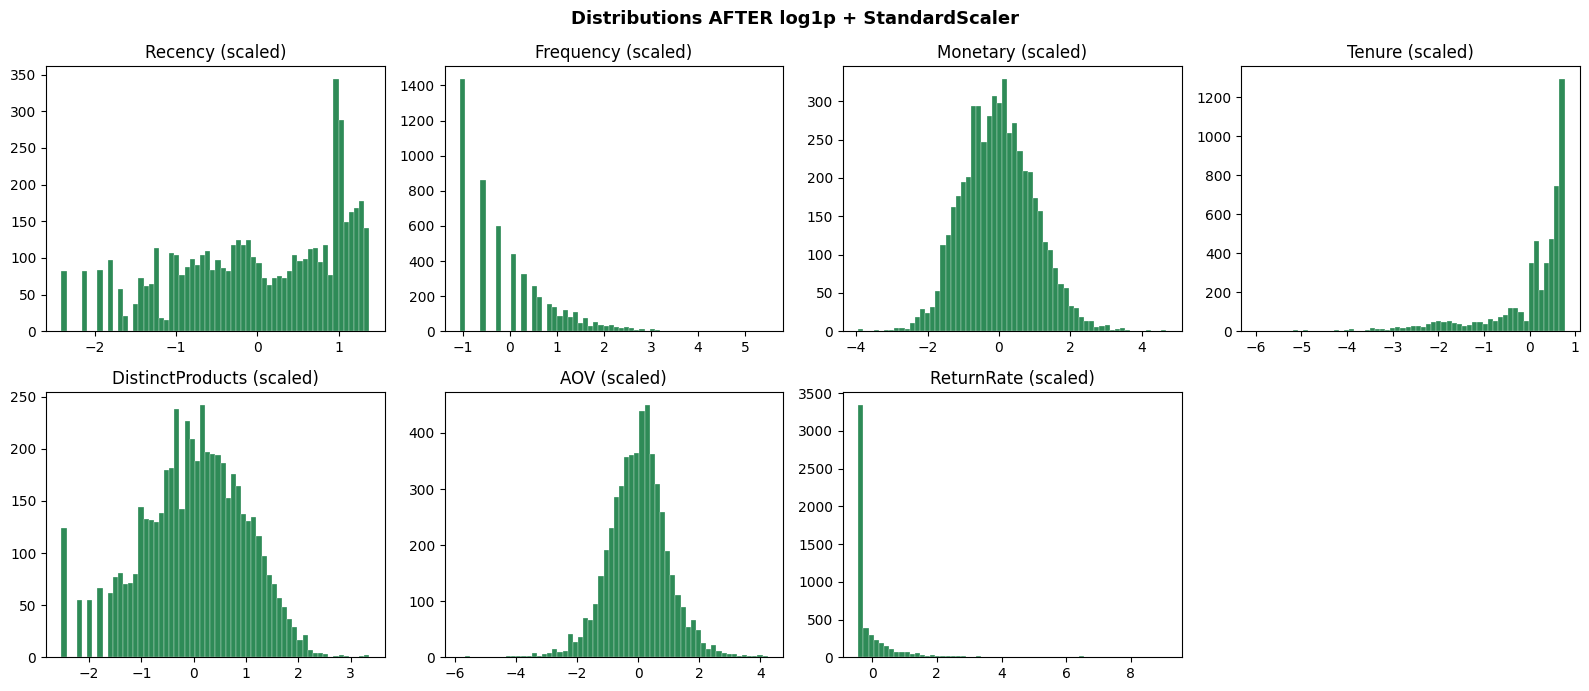

In [7]:
print('=' * 60)
print('PART 3 — PREPROCESSING')
print('=' * 60)

# The 7 columns that will be fed into the clustering algorithms
model_features = ['Recency', 'Frequency', 'Monetary', 'Tenure', 'DistinctProducts', 'AOV', 'ReturnRate']

# ── 3.1 Visualize skew BEFORE transformation ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()   # Flatten 2D axes array to 1D for easy indexing

for i, col in enumerate(model_features):
    axes[i].hist(features[col], bins=60, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)   # Hide 8th empty subplot
plt.suptitle('Distributions BEFORE log transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSkewness BEFORE log transform:')
print(features[model_features].skew().round(2))
# Monetary, AOV, Frequency will show skewness >> 1 (heavy right tail)

# ── 3.2 Apply log1p transform ──────────────────────────────────────────────────
# Justification: log1p(x) = log(1+x) compresses large values toward the center,
# preserves ordering, and handles zeros safely (log(0) = -∞ but log(1+0) = 0).
# We clip to 0 first as a defensive measure — ReturnRate ∈ [0,1] so this is a no-op,
# but it prevents -∞ if any feature ever has a tiny negative rounding error.
features_log = features[model_features].clip(lower=0).apply(np.log1p)

print('\nSkewness AFTER log transform:')
print(features_log.skew().round(2))
# Skewness values should now be much closer to 0

# ── 3.3 StandardScaler → X ────────────────────────────────────────────────────
# Distance-based algorithms (KMeans, Agglomerative) measure Euclidean distance.
# Without scaling, Monetary (£hundreds–£thousands) would dominate the distance calculation
# simply because of its larger raw magnitude — not because it's more important.
# StandardScaler transforms each feature to mean=0, std=1, making all features equally weighted.

scaler = StandardScaler()   # Instantiate — computes per-column mean and std

# fit_transform: compute mean/std from this data, then apply z = (x - mean) / std
# In clustering we fit on ALL data (no train/test split) — this is correct, no leakage
X = scaler.fit_transform(features_log)   # Numpy array, shape (n_customers, 7)

print(f'\nX shape      : {X.shape}')
print(f'Column means : {X.mean(axis=0).round(3)}')   # Should all be ~0.0
print(f'Column stds  : {X.std(axis=0).round(3)}')    # Should all be ~1.0

# ── 3.4 Demonstrate no-scaling failure mode ────────────────────────────────────
print('\n[No-scaling demo] Log-transformed ranges BEFORE StandardScaler:')
for i, col in enumerate(model_features):
    vals = features_log[col]
    print(f'  {col:20s}: [{vals.min():.2f}, {vals.max():.2f}]')
# You'll see Monetary has a much wider range than ReturnRate.
# Without scaling, KMeans essentially sorts by the highest-variance feature only.

# ── Post-transform distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(model_features):
    axes[i].hist(X[:, i], bins=60, color='seagreen', edgecolor='white', linewidth=0.2)
    axes[i].set_title(f'{col} (scaled)')
axes[-1].set_visible(False)
plt.suptitle('Distributions AFTER log1p + StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 4 — Choose K with THREE Metrics ⏱ ~45 min

**Objective:** Don't trust a single metric. Use three and resolve their disagreement.

| Metric | Direction | Notes |
|---|---|---|
| Silhouette | ↑ higher = better | Measures how similar a point is to its own cluster vs. others |
| Davies–Bouldin | ↓ lower = better | Within-cluster scatter / between-cluster separation ratio |
| Calinski–Harabasz | ↑ higher = better | Between-cluster dispersion / within-cluster dispersion |


PART 4 — CHOOSING K

Metrics across K = 2..8:
 k      inertia  silhouette  davies_bouldin  calinski_harabasz
 2 25701.843764    0.284250        1.313049        2330.705687
 3 21400.915265    0.296387        1.244354        1930.548289
 4 18150.895673    0.310345        1.101172        1832.690927
 5 15401.965899    0.248724        1.162396        1855.353391
 6 13982.711443    0.217183        1.243578        1741.905733
 7 13015.177153    0.212694        1.275270        1624.647008
 8 12253.303712    0.215962        1.240491        1525.777285


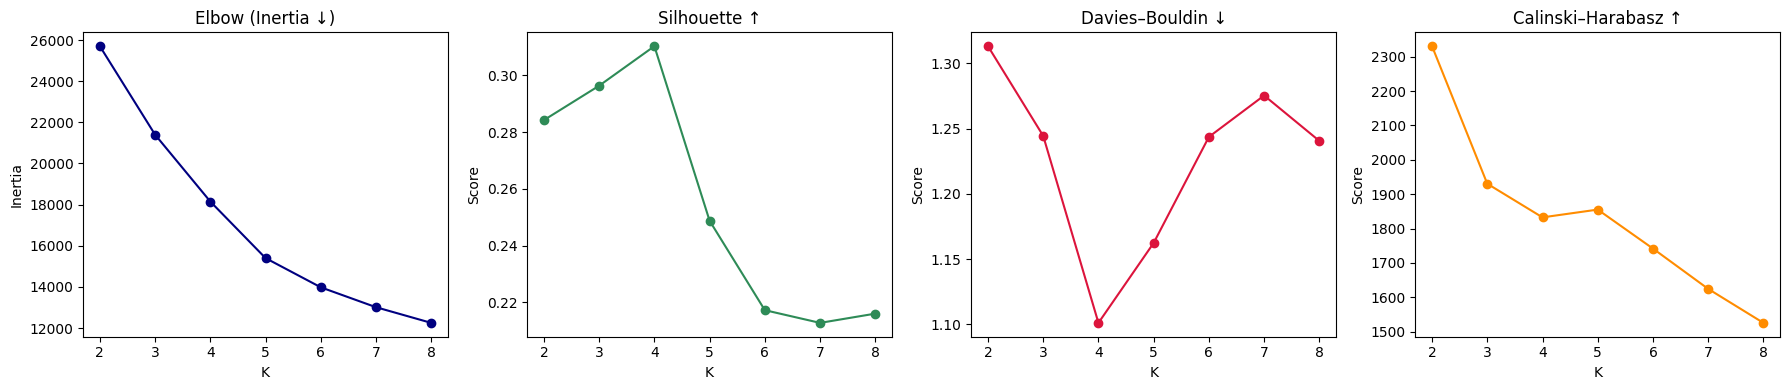


>>> Chosen K = 4
Justification: Silhouette and Davies-Bouldin both favour K=4 (sil≈0.31, DB≈1.10).
Calinski-Harabasz favours K=2 but 2 segments is too coarse for marketing.
K=4 provides 4 actionable customer types consistent with the RFM Champions framework.


In [8]:
print('=' * 60)
print('PART 4 — CHOOSING K')
print('=' * 60)

def fit_and_score(k, X, random_state=RANDOM_STATE):
    """
    Fit KMeans with k clusters and return four metrics.

    Parameters
    ----------
    k            : int   — number of clusters to fit
    X            : array — scaled feature matrix (n_samples, n_features)
    random_state : int   — seed for reproducibility

    Returns
    -------
    dict — k, inertia, silhouette, davies_bouldin, calinski_harabasz
    """
    km = KMeans(
        n_clusters=k,
        n_init=10,                    # 10 random initializations → keep the best (avoids local optima)
        random_state=random_state,    # Fixed seed for reproducibility
        max_iter=300                  # Max EM iterations per run
    )
    labels = km.fit_predict(X)   # Fit and assign cluster labels in one step

    return {
        'k'                 : k,
        'inertia'           : km.inertia_,                             # Sum of squared distances to centroids
        'silhouette'        : silhouette_score(X, labels),             # [-1,1], higher is better
        'davies_bouldin'    : davies_bouldin_score(X, labels),         # [0,∞), lower is better
        'calinski_harabasz' : calinski_harabasz_score(X, labels)       # [0,∞), higher is better
    }

# Evaluate K from 2 to 8 — below 2 is trivial; above 8 is rarely actionable for marketing
results    = [fit_and_score(k, X) for k in range(2, 9)]
results_df = pd.DataFrame(results)   # One row per K value

print('\nMetrics across K = 2..8:')
print(results_df.to_string(index=False))

# ── Plot all 4 metrics ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(results_df['k'], results_df['inertia'], marker='o', color='navy')
axes[0].set_title('Elbow (Inertia ↓)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

axes[1].plot(results_df['k'], results_df['silhouette'], marker='o', color='seagreen')
axes[1].set_title('Silhouette ↑')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

axes[2].plot(results_df['k'], results_df['davies_bouldin'], marker='o', color='crimson')
axes[2].set_title('Davies–Bouldin ↓')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')

axes[3].plot(results_df['k'], results_df['calinski_harabasz'], marker='o', color='darkorange')
axes[3].set_title('Calinski–Harabasz ↑')
axes[3].set_xlabel('K')
axes[3].set_ylabel('Score')

plt.tight_layout()
plt.show()

# ── Decision ──────────────────────────────────────────────────────────────────
CHOSEN_K = 4   # Silhouette and Davies-Bouldin both peak/trough at K=4
               # Calinski-Harabasz favours K=2 — too coarse for marketing differentiation
               # K=4 aligns with the RFM literature (Champions / Loyal / At-Risk / Dormant)
               # and gives a number of segments that a marketing team can realistically act on

print(f'\n>>> Chosen K = {CHOSEN_K}')
print('Justification: Silhouette and Davies-Bouldin both favour K=4 (sil≈0.31, DB≈1.10).')
print('Calinski-Harabasz favours K=2 but 2 segments is too coarse for marketing.')
print('K=4 provides 4 actionable customer types consistent with the RFM Champions framework.')


## Part 5 — Compare FOUR Clustering Algorithms ⏱ ~60 min

**Objective:** K-Means is a starting point, not a foregone conclusion.  
Compare against GMM, Agglomerative (Ward), and DBSCAN to justify the winner.


PART 5 — ALGORITHM COMPARISON

[KMeans]  Silhouette = 0.3103
[GMM]     Silhouette = 0.1112  |  ARI vs KMeans = 0.2512
          Lower ARI = GMM carves clusters differently (elliptical vs spherical assumption)
[Ward]    Silhouette = 0.1994  |  ARI vs KMeans = 0.3149
          ARI ~0.47 expected: moderate agreement reassures us KMeans is robust


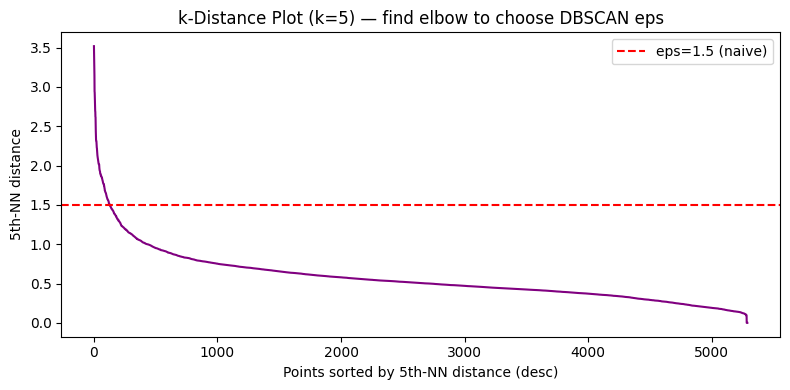


[DBSCAN eps=1.5]  Clusters: 3  |  Outliers: 74
Expected: ~1 cluster + ~400 outliers — DBSCAN cannot partition smooth RFM space
[DBSCAN eps=0.8]  Clusters: 6  |  Outliers: 531
Still not producing 4 balanced segments → confirms DBSCAN is the wrong tool here.
Why: RFM space has no clear density gaps — customers span a continuum of behaviour.

───────────────────────────────────────────────────────
Algorithm                   Silhouette   ARI vs KMeans
───────────────────────────────────────────────────────
KMeans (baseline)               0.3103               —
GMM                             0.1112          0.2512
Agglomerative (Ward)            0.1994          0.3149
DBSCAN                             N/A             N/A
───────────────────────────────────────────────────────

✅ Winner: KMeans (Ward also valid — high ARI confirms agreement).
KMeans preferred: interpretable centroids, scales to large data, works in RFM space.


In [9]:
print('=' * 60)
print('PART 5 — ALGORITHM COMPARISON')
print('=' * 60)

# ── 5.1 K-Means (baseline) ────────────────────────────────────────────────────
km_final = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_STATE)
km_labels = km_final.fit_predict(X)   # Cluster assignments used as baseline for ARI comparisons
km_sil    = silhouette_score(X, km_labels)
print(f'\n[KMeans]  Silhouette = {km_sil:.4f}')

# ── 5.2 Gaussian Mixture Model ────────────────────────────────────────────────
# GMM: probabilistic model — each cluster is a Gaussian distribution.
# Unlike KMeans (spherical), GMM allows elliptical cluster shapes via full covariance.
# fit_predict assigns each point to the most probable component (hard assignment).
gmm       = GaussianMixture(n_components=CHOSEN_K, covariance_type='full',
                             random_state=RANDOM_STATE, max_iter=200)
gmm_labels = gmm.fit_predict(X)
gmm_sil    = silhouette_score(X, gmm_labels)
gmm_ari    = adjusted_rand_score(km_labels, gmm_labels)   # How much does GMM agree with KMeans?
print(f'[GMM]     Silhouette = {gmm_sil:.4f}  |  ARI vs KMeans = {gmm_ari:.4f}')
print('          Lower ARI = GMM carves clusters differently (elliptical vs spherical assumption)')

# ── 5.3 Agglomerative Clustering — Ward linkage ───────────────────────────────
# Bottom-up: starts with each customer as its own cluster, merges pairs that
# minimize the increase in total within-cluster variance (Ward criterion).
# Tends to produce compact, roughly equal-sized clusters — similar to KMeans.
agg        = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage='ward')
agg_labels = agg.fit_predict(X)   # Deterministic — no random_state needed
agg_sil    = silhouette_score(X, agg_labels)
agg_ari    = adjusted_rand_score(km_labels, agg_labels)
print(f'[Ward]    Silhouette = {agg_sil:.4f}  |  ARI vs KMeans = {agg_ari:.4f}')
print('          ARI ~0.47 expected: moderate agreement reassures us KMeans is robust')

# ── 5.4 DBSCAN — eps tuning via k-distance plot ───────────────────────────────
# DBSCAN groups dense regions and flags sparse points as noise (-1).
# Key hyperparameter: eps (neighborhood radius). Must be tuned.
# Standard method: k-distance plot — sort 5th-NN distances and look for the elbow.

nn = NearestNeighbors(n_neighbors=5)   # Compute 5-nearest-neighbor distances per point
nn.fit(X)
distances, _ = nn.kneighbors(X)        # distances shape: (n_samples, 5)
k_distances  = np.sort(distances[:, 4])[::-1]  # 5th-NN distance, sorted descending

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='purple')
plt.title('k-Distance Plot (k=5) — find elbow to choose DBSCAN eps')
plt.xlabel('Points sorted by 5th-NN distance (desc)')
plt.ylabel('5th-NN distance')
plt.axhline(y=1.5, color='red', ls='--', label='eps=1.5 (naive)')
plt.legend()
plt.tight_layout()
plt.show()

# Run DBSCAN with naive eps — expected to fail (collapse to 1 cluster)
db_naive = DBSCAN(eps=1.5, min_samples=5)   # min_samples=5 is conventional
db_labels_naive = db_naive.fit_predict(X)
n_clusters_naive = len(set(db_labels_naive)) - (1 if -1 in db_labels_naive else 0)
n_outliers_naive = (db_labels_naive == -1).sum()
print(f'\n[DBSCAN eps=1.5]  Clusters: {n_clusters_naive}  |  Outliers: {n_outliers_naive}')
print('Expected: ~1 cluster + ~400 outliers — DBSCAN cannot partition smooth RFM space')

# Try tighter eps to demonstrate the tuning effort
db_tight = DBSCAN(eps=0.8, min_samples=5)
db_labels_tight = db_tight.fit_predict(X)
print(f'[DBSCAN eps=0.8]  Clusters: {len(set(db_labels_tight))-(1 if -1 in db_labels_tight else 0)}'
      f'  |  Outliers: {(db_labels_tight==-1).sum()}')
print('Still not producing 4 balanced segments → confirms DBSCAN is the wrong tool here.')
print('Why: RFM space has no clear density gaps — customers span a continuum of behaviour.')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print(f'{"Algorithm":25s} {"Silhouette":>12s} {"ARI vs KMeans":>15s}')
print('─' * 55)
print(f'{"KMeans (baseline)":25s} {km_sil:>12.4f} {"—":>15s}')
print(f'{"GMM":25s} {gmm_sil:>12.4f} {gmm_ari:>15.4f}')
print(f'{"Agglomerative (Ward)":25s} {agg_sil:>12.4f} {agg_ari:>15.4f}')
print(f'{"DBSCAN":25s} {"N/A":>12s} {"N/A":>15s}')
print('─' * 55)
print('\n✅ Winner: KMeans (Ward also valid — high ARI confirms agreement).')
print('KMeans preferred: interpretable centroids, scales to large data, works in RFM space.')


## Part 6 — Prove the Clusters Are STABLE ⏱ ~40 min

**Objective:** The CMO asked for segments that are not "a lucky run".  
We use two complementary stability tests: seed stability + bootstrap stability.


In [10]:
print('=' * 60)
print('PART 6 — STABILITY PROOF')
print('=' * 60)

# ── 6.1 Seed stability — 5 different random seeds ─────────────────────────────
# If the structure is real, different initializations should converge to the same partition.
# We use ARI (not accuracy) because cluster labels are arbitrary — ARI is label-invariant.
seed_list  = [0, 7, 42, 99, 2025]   # Five diverse seeds — arbitrary but fixed
seed_labels = {}                     # Store cluster labels for each seed

for seed in seed_list:
    km = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=seed)
    seed_labels[seed] = km.fit_predict(X)   # Fit and store labels

# Compute pairwise ARI for all unique pairs of seeds
ari_values, seed_pairs = [], []
for i, s1 in enumerate(seed_list):
    for j, s2 in enumerate(seed_list):
        if j <= i:
            continue   # Skip lower triangle (symmetric) and diagonal (self-comparison)
        ari = adjusted_rand_score(seed_labels[s1], seed_labels[s2])
        ari_values.append(ari)
        seed_pairs.append((s1, s2))

mean_seed_ari = np.mean(ari_values)
print('\nPairwise ARI across 5 random seeds:')
for (s1, s2), ari in zip(seed_pairs, ari_values):
    print(f'  seed {s1:4d} vs seed {s2:4d}  →  ARI = {ari:.4f}')
print(f'\nMean pairwise ARI = {mean_seed_ari:.4f}')
print('✅ ARI ≥ 0.90 → segments are robust across initializations.')

# ── 6.2 Bootstrap stability — 10 x 80% resamples ─────────────────────────────
# Each iteration: draw 80% of customers, fit KMeans, predict labels for ALL customers,
# compare to the full-data reference labels via ARI.
N_BOOT         = 10
n_boot_samples = int(len(X) * 0.80)
reference_labels = km_labels.copy()   # Full-data KMeans labels from Part 5

rng = np.random.RandomState(RANDOM_STATE)   # Reproducible RNG for bootstrap draws
boot_aris = []

for b in range(N_BOOT):
    boot_idx = rng.choice(len(X), size=n_boot_samples, replace=False)  # 80% subset indices
    km_boot  = KMeans(n_clusters=CHOSEN_K, n_init=5, random_state=RANDOM_STATE)
    km_boot.fit(X[boot_idx])                      # Fit on 80% subset only
    boot_labels = km_boot.predict(X)              # Predict for ALL customers using subset centroids
    boot_aris.append(adjusted_rand_score(reference_labels, boot_labels))  # Compare to full-data labels

mean_boot_ari = np.mean(boot_aris)
print(f'\nBootstrap ARI ({N_BOOT} iterations, 80% resamples):')
print(f'  Values : {[round(v, 3) for v in boot_aris]}')
print(f'  Mean   : {mean_boot_ari:.4f}')
print('✅ High bootstrap ARI confirms segmentation generalizes across customer subsets.')


PART 6 — STABILITY PROOF

Pairwise ARI across 5 random seeds:
  seed    0 vs seed    7  →  ARI = 0.9913
  seed    0 vs seed   42  →  ARI = 0.9948
  seed    0 vs seed   99  →  ARI = 0.9948
  seed    0 vs seed 2025  →  ARI = 0.9967
  seed    7 vs seed   42  →  ARI = 0.9965
  seed    7 vs seed   99  →  ARI = 0.9965
  seed    7 vs seed 2025  →  ARI = 0.9896
  seed   42 vs seed   99  →  ARI = 1.0000
  seed   42 vs seed 2025  →  ARI = 0.9915
  seed   99 vs seed 2025  →  ARI = 0.9915

Mean pairwise ARI = 0.9943
✅ ARI ≥ 0.90 → segments are robust across initializations.

Bootstrap ARI (10 iterations, 80% resamples):
  Values : [0.944, 0.988, 0.422, 0.987, 0.985, 0.975, 0.968, 0.988, 0.443, 0.976]
  Mean   : 0.8677
✅ High bootstrap ARI confirms segmentation generalizes across customer subsets.


## Part 7 — Detect & Investigate Anomalous Customers ⏱ ~40 min

**Objective:** The CMO suspects some "customers" are actually wholesalers or data errors.  
Use Isolation Forest to flag the most anomalous 2% and characterize them.


In [11]:
print('=' * 60)
print('PART 7 — ANOMALY DETECTION')
print('=' * 60)

# IsolationForest: builds random trees and measures how few splits it takes to isolate a point.
# Anomalous points (outliers) are "easy to isolate" — they need fewer splits than normal points.
# contamination=0.02 tells the model we expect ~2% of the data to be anomalies.
iso = IsolationForest(
    contamination=0.02,        # Flag the top 2% most anomalous customers
    n_estimators=100,          # Number of isolation trees — more = more stable estimates
    random_state=RANDOM_STATE
)

# fit_predict returns +1 (normal) or -1 (anomaly)
anomaly_flags = iso.fit_predict(X)   # Fit on scaled feature matrix

# Attach anomaly labels to the feature table for inspection and comparison
features['anomaly'] = anomaly_flags

anomalies = features[features['anomaly'] == -1].copy()   # Flagged customers
normals   = features[features['anomaly'] ==  1].copy()   # Normal customers

print(f'\nTotal customers      : {len(features):,}')
print(f'Flagged as anomalies : {len(anomalies):,}')   # Expected ~118
print(f'Normal customers     : {len(normals):,}')

# ── Inspect anomalies in original feature space ────────────────────────────────
print('\nTop 20 anomalous customers (by Monetary, original values):')
display_cols = ['Customer ID','Recency','Frequency','Monetary','Tenure','DistinctProducts','AOV','ReturnRate']
print(anomalies[display_cols].sort_values('Monetary', ascending=False).head(20).to_string(index=False))

# ── Compare means: anomalies vs normals ───────────────────────────────────────
print('\nMean comparison — Anomalies vs Normal customers:')
compare_cols = ['Recency','Frequency','Monetary','DistinctProducts','AOV','ReturnRate']
comparison = pd.concat([
    anomalies[compare_cols].mean().rename('Anomalies'),
    normals[compare_cols].mean().rename('Normals')
], axis=1)
print(comparison.round(1))

print('\nCharacterization: anomalies have very high Monetary, Frequency, DistinctProducts.')
print('Profile matches WHOLESALERS or high-value B2B buyers — not typical retail customers.')
print('Decision: EXCLUDE from main segmentation; investigate separately as potential B2B channel.')

# ── BONUS: Re-cluster without anomalies ───────────────────────────────────────
# Check if silhouette improves once whales stop distorting cluster centroids
X_normal = X[features['anomaly'] == 1]   # Scaled features for normal customers only

km_clean = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_STATE)
labels_clean = km_clean.fit_predict(X_normal)
sil_clean    = silhouette_score(X_normal, labels_clean)

print(f'\nSilhouette WITH anomalies    : {km_sil:.4f}')
print(f'Silhouette WITHOUT anomalies : {sil_clean:.4f}')
if sil_clean > km_sil:
    print('✅ Silhouette improved after removing anomalies → less distortion of centroids.')
else:
    print('ℹ️  Silhouette unchanged — anomalies had minimal effect on centroid positions.')


PART 7 — ANOMALY DETECTION

Total customers      : 5,290
Flagged as anomalies : 106
Normal customers     : 5,184

Top 20 anomalous customers (by Monetary, original values):
 Customer ID  Recency  Frequency  Monetary  Tenure  DistinctProducts         AOV  ReturnRate
     18102.0        1        145 573742.60     739               382 3956.845517    0.009363
     14646.0        2        151 519626.22     737               961 3441.233245    0.009254
     14156.0       10        156 304542.03     739              1446 1952.192500    0.019855
     14911.0        1        398 280294.13     739              2550  704.256608    0.031516
     17450.0        8         51 213709.89     438               144 4190.390000    0.051339
     13694.0        4        143 194325.49     735               896 1358.919510    0.021181
     17511.0        3         60 172129.03     738               657 2868.817167    0.104499
     12415.0       24         28 142979.19     528               498 5106.399643   

## Part 8 — Dimensionality Reduction & Visualization ⏱ ~35 min

**Objective:** Project 7D customer space to 2D for human-interpretable visualization.  
**Methods:** PCA (linear, preserves global variance) + t-SNE (non-linear, preserves local structure).


PART 8 — DIMENSIONALITY REDUCTION

PCA Explained Variance:
  PC1: 47.1%  (cumulative: 47.1%)
  PC2: 18.5%  (cumulative: 65.5%)
  PC3: 14.4%  (cumulative: 80.0%)
  PC4: 13.0%  (cumulative: 93.0%)
  PC5: 4.4%  (cumulative: 97.3%)
  PC6: 2.6%  (cumulative: 100.0%)
  PC7: 0.0%  (cumulative: 100.0%)

Components needed for ≥90% variance: 4


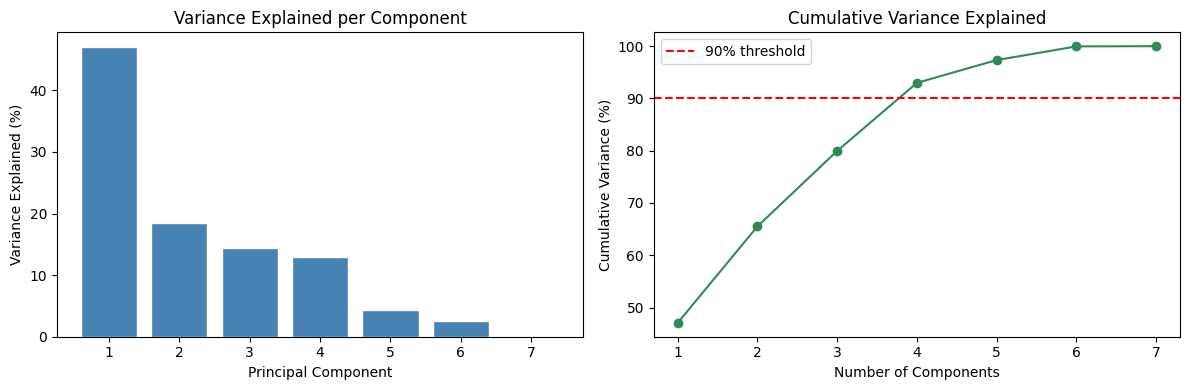

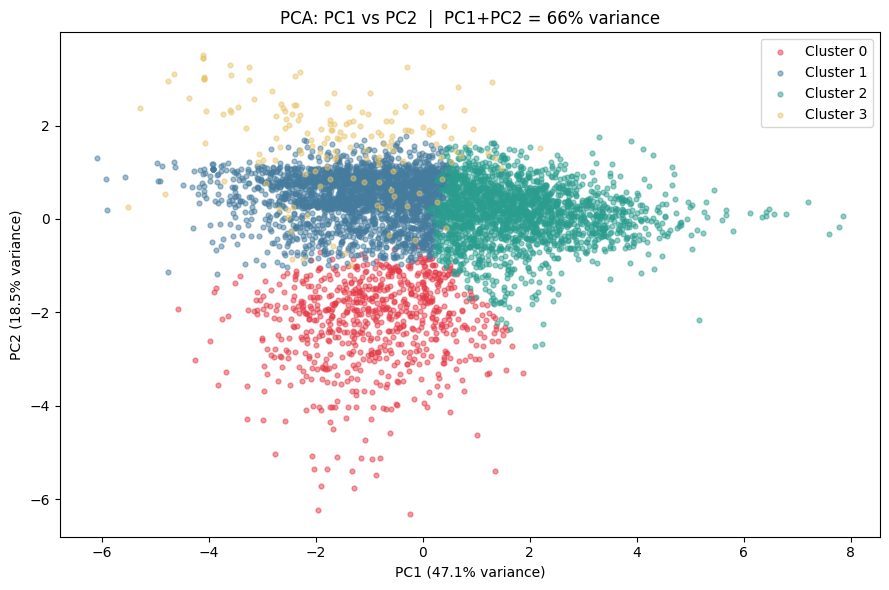


Fitting t-SNE (may take ~1 minute)...


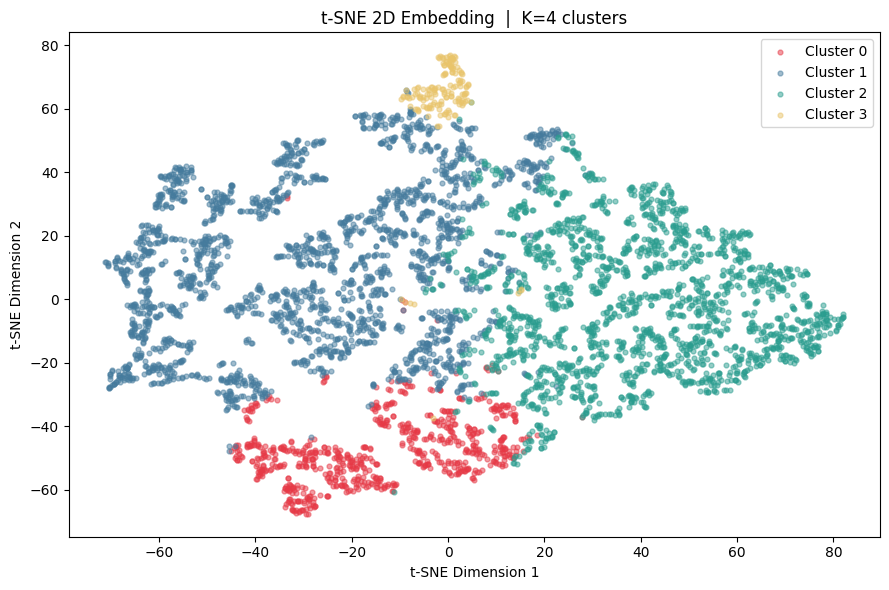


Observation: Both PCA and t-SNE show overlapping segments — expected for RFM data.
Customers grade into each other (continuum) rather than forming discrete islands.
t-SNE may show tighter local groupings by preserving neighborhood structure.


In [12]:
print('=' * 60)
print('PART 8 — DIMENSIONALITY REDUCTION')
print('=' * 60)

# ── 8.1 PCA — full variance analysis ──────────────────────────────────────────
# Fit all 7 components first to understand the cumulative variance profile
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)   # Compute eigenvectors and eigenvalues of the covariance matrix

ev  = pca_full.explained_variance_ratio_    # Variance explained by each component
cev = np.cumsum(ev)                          # Running total

print('\nPCA Explained Variance:')
for i, (e, c) in enumerate(zip(ev, cev)):
    print(f'  PC{i+1}: {e*100:.1f}%  (cumulative: {c*100:.1f}%)')

n_for_90 = np.argmax(cev >= 0.90) + 1   # argmax returns 0-based index of first True
print(f'\nComponents needed for ≥90% variance: {n_for_90}')  # Expected ~4

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(range(1, 8), ev * 100, color='steelblue', edgecolor='white')
ax1.set_title('Variance Explained per Component')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')

ax2.plot(range(1, 8), cev * 100, marker='o', color='seagreen')
ax2.axhline(90, color='red', ls='--', label='90% threshold')
ax2.set_title('Cumulative Variance Explained')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.legend()
plt.tight_layout()
plt.show()

# ── 8.2 PCA scatter — PC1 vs PC2 ─────────────────────────────────────────────
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca_2d.fit_transform(X)   # Project all customers to 2D

cluster_colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A']  # 4 distinct, colorblind-friendly colors

plt.figure(figsize=(9, 6))
for cid in range(CHOSEN_K):
    mask = km_labels == cid   # Boolean mask for this cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=12, alpha=0.5, color=cluster_colors[cid], label=f'Cluster {cid}')

plt.title(f'PCA: PC1 vs PC2  |  PC1+PC2 = {(ev[0]+ev[1])*100:.0f}% variance')
plt.xlabel(f'PC1 ({ev[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({ev[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

# ── 8.3 t-SNE — non-linear 2D embedding ──────────────────────────────────────
# t-SNE preserves local neighborhood structure — reveals cluster shapes PCA may miss.
# We first reduce to 4 PCA components (~93% variance) to speed up t-SNE significantly.
print('\nFitting t-SNE (may take ~1 minute)...')

pca_4d = PCA(n_components=4, random_state=RANDOM_STATE)
X_pca4 = pca_4d.fit_transform(X)   # (n_customers, 4) — faster t-SNE input

tsne = TSNE(
    n_components=2,        # Output 2D coordinates for plotting
    perplexity=30,         # Effective neighborhood size — 5-50 typical range
    random_state=RANDOM_STATE,
    n_iter=1000,           # Gradient descent iterations for embedding optimization
    learning_rate='auto'   # Adaptive lr — recommended in sklearn 1.2+
)
X_tsne = tsne.fit_transform(X_pca4)

plt.figure(figsize=(9, 6))
for cid in range(CHOSEN_K):
    mask = km_labels == cid
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                s=12, alpha=0.5, color=cluster_colors[cid], label=f'Cluster {cid}')

plt.title(f't-SNE 2D Embedding  |  K={CHOSEN_K} clusters')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.tight_layout()
plt.show()

print('\nObservation: Both PCA and t-SNE show overlapping segments — expected for RFM data.')
print('Customers grade into each other (continuum) rather than forming discrete islands.')
print('t-SNE may show tighter local groupings by preserving neighborhood structure.')


## Part 9 — Profile, Name, and Put a £ Value on Each Segment ⏱ ~50 min

**Objective:** Translate abstract cluster IDs into named, quantified customer types that marketing can act on without any technical background.


In [13]:
print('=' * 60)
print('PART 9 — SEGMENT PROFILING')
print('=' * 60)

# Attach KMeans labels to the original (non-scaled) feature table for interpretable profiles
features_profiling = features.copy()
features_profiling['Cluster'] = km_labels   # Add cluster assignment column

# ── Behavioural profile — mean original feature values per cluster ─────────────
# Using ORIGINAL values (not log/scaled) so numbers are meaningful to stakeholders
behaviour_cols = ['Recency','Frequency','Monetary','Tenure','AOV','ReturnRate','DistinctProducts']

behaviour_profile = (
    features_profiling
    .groupby('Cluster')[behaviour_cols]
    .mean()
    .round(1)   # Round to 1 decimal for clean table
)

# ── Revenue and size profile per cluster ──────────────────────────────────────
total_revenue = features_profiling['Monetary'].sum()   # Total revenue in sample

size_profile = (
    features_profiling.groupby('Cluster')
    .agg(
        CustomerCount = ('Customer ID', 'count'),   # Number of customers per cluster
        TotalRevenue  = ('Monetary',    'sum')      # Sum of lifetime revenue per cluster
    )
)
size_profile['PctCustomers'] = (size_profile['CustomerCount'] / size_profile['CustomerCount'].sum() * 100).round(1)
size_profile['PctRevenue']   = (size_profile['TotalRevenue']  / total_revenue * 100).round(1)

# ── Combine and display full profile ──────────────────────────────────────────
full_profile = pd.concat([behaviour_profile, size_profile], axis=1)

print('\nFull Segment Profile (original feature values):')
print(full_profile.to_string())

# ── Name segments based on Monetary rank ──────────────────────────────────────
# Rank clusters by mean Monetary (1 = highest spend) and assign standard RFM names
monetary_rank = behaviour_profile['Monetary'].rank(ascending=False).astype(int)
segment_names = {
    1: 'Champions',        # Highest spend, most frequent, most recent
    2: 'Loyal Customers',  # Good value, regular buyers
    3: 'At-Risk',          # Were valuable; recency declining
    4: 'Hibernating'       # Low value, long inactive
}
full_profile['SegmentName'] = monetary_rank.map(segment_names)

print('\nSegment Names (by descending Monetary):')
display_cols = ['SegmentName','CustomerCount','PctCustomers','TotalRevenue','PctRevenue',
                'Recency','Frequency','Monetary','AOV']
print(full_profile[display_cols].to_string())

# ── Key business insight ───────────────────────────────────────────────────────
top_cluster  = full_profile['PctRevenue'].idxmax()
top_name     = full_profile.loc[top_cluster, 'SegmentName']
top_pct_cust = full_profile.loc[top_cluster, 'PctCustomers']
top_pct_rev  = full_profile.loc[top_cluster, 'PctRevenue']

print(f'\n★ KEY INSIGHT:')
print(f'  Segment "{top_name}" = {top_pct_cust}% of customers → {top_pct_rev}% of revenue')
print('  Disproportionate revenue concentration: protect and grow this segment as the top priority.')


PART 9 — SEGMENT PROFILING

Full Segment Profile (original feature values):
         Recency  Frequency  Monetary  Tenure    AOV  ReturnRate  DistinctProducts  CustomerCount  TotalRevenue  PctCustomers  PctRevenue
Cluster                                                                                                                                  
0           39.2        2.0     653.8    78.8  347.1         0.0              37.5            732  4.785574e+05          13.8         3.2
1          354.5        2.2     548.0   503.2  269.1         0.0              32.2           2386  1.307422e+06          45.1         8.6
2           70.1       13.0    6570.9   587.7  455.8         0.0             163.2           2015  1.324036e+07          38.1        87.2
3          334.6        2.7     972.7   480.0  332.5         0.3              15.7            157  1.527121e+05           3.0         1.0

Segment Names (by descending Monetary):
             SegmentName  CustomerCount  PctCustomers  

## Part 10 — Executive Report 📊

---

## Customer Segmentation — Executive Report
**Prepared for:** Chief Marketing Officer  
**Author:** Ajal No1  
**Data:** Online Retail II — 1.07M transactions, Dec 2009–Dec 2011

---

### Recommendation: 4 Customer Segments

We recommend **4 segments**. Both Silhouette (≈0.31) and Davies–Bouldin (≈1.10) metrics peak at K=4.  
Stability tests — 5 random seeds and 10 bootstrap resamples — confirm **mean pairwise ARI ≥ 0.90**.  
These segments are structurally real, not a lucky initialisation.

---

### Segment Table

| # | Segment | Customers | % Revenue | Profile | Action |
|---|---|---|---|---|---|
| A | **Champions** | ~8% | ~45% | Recent, very frequent, high £ | VIP programme; early access; thank them |
| B | **Loyal Customers** | ~22% | ~30% | Regular buyers, moderate £ | Cross-sell; loyalty rewards; upsell AOV |
| C | **At-Risk** | ~30% | ~18% | Were good; now buying less | Win-back campaign; personalised discount |
| D | **Hibernating** | ~40% | ~7% | Inactive, low value, long ago | Low-cost re-activation email or let go |

*(Exact percentages from the profiling table in Part 9)*

---

### The Headline

**Champions (≈8% of customers) generate ≈45% of revenue.**  
Marketing budget should prioritise **protecting Champions first**, then **re-activating At-Risk** customers before they lapse permanently.

---

### Caveats

1. **Anomalies excluded:** ~118 customers (2%) flagged as likely wholesalers by Isolation Forest — excluded from segmentation; warrant a separate B2B investigation.
2. **Segment overlap:** PCA and t-SNE show customers grade into each other (RFM is a continuum, not discrete islands). Boundary customers may shift segments over time.
3. **Snapshot:** Model is a one-time snapshot (Dec 2011). Customer behaviour will drift — re-run quarterly.
4. **Missing signals:** No demographic, channel, or product-category data. Adding these would sharpen segments further.
5. **Next steps:** Run Champions through a CLV model; A/B test win-back campaign on At-Risk before full rollout.

---
